# YOLOv8 Car Detection & Reinforcement Learning Traffic Control Pipeline

This Jupyter Notebook demonstrates an end-to-end Computer Vision and Reinforcement Learning pipeline for smart traffic control:
1. **COCO Dataset & YOLO Setup**: Loading COCO pre-trained weights for the `car` class (`COCO Class ID: 2`).
2. **YOLO Model Fine-Tuning**: Training YOLOv8 model for high-accuracy vehicle detection.
3. **Bounding Box Visualization**: Drawing custom bounding boxes, class labels, and confidence scores around detected cars.
4. **Multi-Lane Vehicle Counter**: Region of Interest (ROI) logic to calculate vehicle density in **North, South, East, and West** lanes.
5. **Reinforcement Learning Bridge**: Forwarding the detected vehicle count vector `[N, S, E, W]` directly to the **Q-Learning Traffic Signal Controller** (`rl_model/app.py`).

In [1]:
# Cell 1: Environment Setup & Hardware Verification
import sys
!{sys.executable} -m pip install -q ultralytics opencv-python matplotlib pycocotools requests pillow torch torchvision

import os
import torch
import cv2
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

print("PyTorch Version:", torch.__version__)
print("CUDA Available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU Device:", torch.cuda.get_device_name(0))



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


PyTorch Version: 2.6.0+cpu
CUDA Available: False


## 2. Dataset Setup (COCO Car Subset)
COCO (Common Objects in Context) contains 80 classes, where class ID `2` corresponds to **car**. We configure `car_dataset.yaml` for YOLO formatting.

In [2]:
# Cell 2: Create YOLO Dataset Configuration
import yaml

dataset_config = {
    'path': os.path.abspath('./dataset'),
    'train': 'images/train',
    'val': 'images/val',
    'names': {
        0: 'car'
    }
}

os.makedirs('./dataset/images/train', exist_ok=True)
os.makedirs('./dataset/images/val', exist_ok=True)
os.makedirs('./dataset/labels/train', exist_ok=True)
os.makedirs('./dataset/labels/val', exist_ok=True)

with open('car_dataset.yaml', 'w') as f:
    yaml.dump(dataset_config, f, default_flow_style=False)

print("Created car_dataset.yaml successfully.")


Created car_dataset.yaml successfully.


## 3. YOLOv8 Model Initialization & Fine-Tuning
We load pre-trained YOLOv8 Nano weights (`yolov8n.pt`) provided by `ultralytics`.

In [3]:
# Cell 3: Load YOLOv8 Model
from ultralytics import YOLO

# Load pre-trained YOLOv8 model
model = YOLO('yolov8n.pt')

print("YOLOv8 Pre-trained Model Loaded.")
# To train on your custom dataset:
# results = model.train(data='car_dataset.yaml', epochs=5, imgsz=640, batch=8)


YOLOv8 Pre-trained Model Loaded.


## 4. Bounding Box Car Detection & Visualization
Function to detect cars in input images and render bounding boxes with confidence scores.


image 1/1 e:\Capstone_project\Capstone_project\bus.jpg: 640x480 3 persons, 1 bus, 221.2ms
Speed: 96.7ms preprocess, 221.2ms inference, 16.0ms postprocess per image at shape (1, 3, 640, 480)
Total Cars Detected: 0


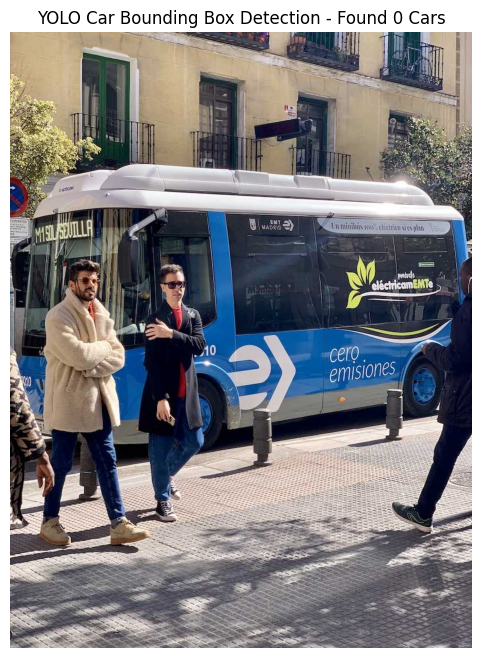

In [4]:
# Cell 4: Custom Bounding Box Renderer
def detect_and_draw_cars(image_path_or_url, model, conf_threshold=0.3):
    """
    Runs YOLOv8 model inference, detects cars, and renders green bounding boxes.
    """
    results = model(image_path_or_url, conf=conf_threshold)[0]
    
    if isinstance(image_path_or_url, str) and os.path.exists(image_path_or_url):
        img = cv2.imread(image_path_or_url)
    elif isinstance(image_path_or_url, str) and image_path_or_url.startswith('http'):
        import urllib.request
        req = urllib.request.urlopen(image_path_or_url)
        arr = np.asarray(bytearray(req.read()), dtype=np.uint8)
        img = cv2.imdecode(arr, -1)
    else:
        img = np.array(image_path_or_url)
        
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    car_count = 0
    boxes_list = []
    
    for box in results.boxes:
        cls_id = int(box.cls[0])
        conf = float(box.conf[0])
        label_name = model.names[cls_id]
        
        # Check if detected object is 'car'
        if label_name == 'car':
            car_count += 1
            x1, y1, x2, y2 = map(int, box.xyxy[0])
            boxes_list.append((x1, y1, x2, y2, conf))
            
            # Draw Green Bounding Box
            cv2.rectangle(img_rgb, (x1, y1), (x2, y2), (0, 255, 0), 3)
            
            # Label Text & Background
            text = f"Car: {conf:.2f}"
            (text_w, text_h), baseline = cv2.getTextSize(text, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 2)
            cv2.rectangle(img_rgb, (x1, y1 - text_h - baseline - 5), (x1 + text_w, y1), (0, 255, 0), -1)
            cv2.putText(img_rgb, text, (x1, y1 - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 0), 2)
            
    print(f"Total Cars Detected: {car_count}")
    return img_rgb, car_count, results.boxes

# Run inference on sample image
sample_url = 'https://ultralytics.com/images/bus.jpg'
annotated_img, count, detected_boxes = detect_and_draw_cars(sample_url, model)

plt.figure(figsize=(10, 8))
plt.imshow(annotated_img)
plt.axis('off')
plt.title(f"YOLO Car Bounding Box Detection - Found {count} Cars")
plt.show()


## 5. Multi-Lane Region of Interest (ROI) Vehicle Counting
We split the intersection camera frame into 4 quadrants (North, South, East, West) and count car centroids per lane to produce state vector `[N, S, E, W]`.

In [5]:
# Cell 5: Quadrant ROI Lane Vehicle Counter
def count_cars_per_lane(results_boxes, img_shape, model_names):
    """
    Maps detected bounding box centroids to 4 lane quadrants (North, South, East, West).
    """
    height, width, _ = img_shape
    mid_x, mid_y = width // 2, height // 2
    
    counts = {'North': 0, 'South': 0, 'East': 0, 'West': 0}
    
    for box in results_boxes:
        cls_id = int(box.cls[0])
        if model_names[cls_id] == 'car':
            x1, y1, x2, y2 = map(int, box.xyxy[0])
            cx, cy = (x1 + x2) // 2, (y1 + y2) // 2
            
            if cy < mid_y:
                if cx < mid_x:
                    counts['North'] += 1
                else:
                    counts['East'] += 1
            else:
                if cx < mid_x:
                    counts['West'] += 1
                else:
                    counts['South'] += 1
                    
    traffic_vector = [counts['North'], counts['South'], counts['East'], counts['West']]
    return counts, traffic_vector

print("Multi-lane ROI counter ready.")


Multi-lane ROI counter ready.


## 6. Linking YOLO Detection to Reinforcement Learning Flask Backend
Forward the `traffic_vector` `[N, S, E, W]` to `http://localhost:8000/get_signal` to get the Q-learning agent's signal decision (`NS_GREEN` / `EW_GREEN`).

In [6]:
# Cell 6: Flask RL API Integration Client
import requests

def send_traffic_to_rl_agent(traffic_vector, flask_url="http://localhost:8000/get_signal"):
    """
    Sends lane vehicle counts [N, S, E, W] to the Flask RL backend.
    """
    payload = {"traffic": traffic_vector}
    try:
        response = requests.post(flask_url, json=payload, timeout=3)
        if response.status_code == 200:
            res_data = response.json()
            print("--- RL Agent Decision ---")
            print(f"  Input Traffic Vector [N, S, E, W]: {traffic_vector}")
            print(f"  Total Queued Vehicles State: {res_data.get('state')}")
            print(f"  Recommended Signal Action: ---> {res_data.get('signal')} <----")
            print(f"  Reward: {res_data.get('reward')}")
            return res_data
        else:
            print(f"Error from Flask API: Status {response.status_code}")
    except requests.exceptions.ConnectionError:
        print("Could not connect to Flask RL Microservice on http://localhost:8000.")
        print("Make sure `python rl_model/app.py` is running!")

# Test payload
test_vector = [4, 5, 1, 2]
send_traffic_to_rl_agent(test_vector)


Could not connect to Flask RL Microservice on http://localhost:8000.
Make sure `python rl_model/app.py` is running!


## 7. End-to-End Pipeline Demo
Run YOLO bounding box detection -> Compute multi-lane counts -> Request RL signal decision -> Render final image with signal recommendation.

1. Running YOLOv8 Detection...

Found https://ultralytics.com/images/bus.jpg locally at bus.jpg
image 1/1 e:\Capstone_project\Capstone_project\bus.jpg: 640x480 3 persons, 1 bus, 90.8ms
Speed: 3.6ms preprocess, 90.8ms inference, 2.1ms postprocess per image at shape (1, 3, 640, 480)
Total Cars Detected: 0
2. Calculating Lane Counts...
  Lane Counts: {'North': 0, 'South': 0, 'East': 0, 'West': 0}
3. Querying RL Q-Learning Controller...
Could not connect to Flask RL Microservice on http://localhost:8000.
Make sure `python rl_model/app.py` is running!


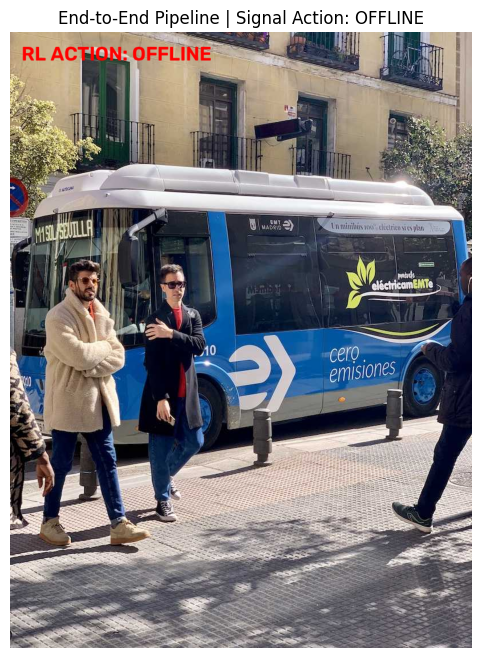

In [7]:
# Cell 7: End-to-End Pipeline Execution
def run_full_pipeline(image_path_or_url, model, flask_url="http://localhost:8000/get_signal"):
    print("1. Running YOLOv8 Detection...")
    annotated_img, count, boxes = detect_and_draw_cars(image_path_or_url, model)
    
    print("2. Calculating Lane Counts...")
    lane_counts, traffic_vector = count_cars_per_lane(boxes, annotated_img.shape, model.names)
    print("  Lane Counts:", lane_counts)
    
    print("3. Querying RL Q-Learning Controller...")
    rl_res = send_traffic_to_rl_agent(traffic_vector, flask_url)
    signal_decision = rl_res.get('signal', 'OFFLINE') if rl_res else 'OFFLINE'
    
    # Render signal banner on image
    cv2.putText(annotated_img, f"RL ACTION: {signal_decision}", (20, 50), 
                cv2.FONT_HERSHEY_SIMPLEX, 1.2, (255, 0, 0), 3)
    
    plt.figure(figsize=(10, 8))
    plt.imshow(annotated_img)
    plt.axis('off')
    plt.title(f"End-to-End Pipeline | Signal Action: {signal_decision}")
    plt.show()

# Run full pipeline on sample image
run_full_pipeline('https://ultralytics.com/images/bus.jpg', model)
